In [0]:
from pyspark.sql import functions as F
from pyspark.sql import Window

BRONZE  = "mvp_jogos.bronze.vgsales_raw"
SILVER  = "mvp_jogos.silver.jogos_vendas"
MAP_TBL = "mvp_jogos.silver.map_console"

In [0]:
MAP_CONSOLE = {
 "PC": ("PC", "PC"), "MS": ("PC (MS-DOS)", "PC"), "OSX": ("MacOS", "PC"), "Linux": ("Linux", "PC"),
 "And": ("Android", "Mobile"), "iOS": ("iOS", "Mobile"), "Mob": ("Mobile", "Mobile"), "WinP": ("Windows Phone", "Mobile"),
 "PS": ("PlayStation (PS1)", "PlayStation"), "PS2": ("PlayStation 2", "PlayStation"),
 "PS3": ("PlayStation 3", "PlayStation"), "PS4": ("PlayStation 4", "PlayStation"),
 "PS5": ("PlayStation 5", "PlayStation"), "PSP": ("PSP", "PlayStation"),
 "PSV": ("PS Vita", "PlayStation"), "PSN": ("PlayStation Network (digital)", "PlayStation"),
 "XB": ("Xbox (1995)", "Xbox"), "XBL": ("Xbox (Original)", "Xbox"), "X360": ("Xbox 360", "Xbox"),
 "XOne": ("Xbox One", "Xbox"), "XS": ("Xbox Series", "Xbox"), "Series": ("Xbox Series", "Xbox"),
 "NES": ("Nintendo (NES)", "Nintendo"), "SNES": ("Super Nintendo (SNES)", "Nintendo"), "N64": ("Nintendo 64", "Nintendo"),
 "GC": ("Nintendo GameCube", "Nintendo"), "Wii": ("Wii", "Nintendo"), "WiiU": ("Wii U", "Nintendo"),
 "DS": ("DS", "Nintendo"), "DSi": ("DSi", "Nintendo"), "DSiW": ("DSiWare", "Nintendo"),
 "3DS": ("3DS", "Nintendo"), "NS": ("Nintendo Switch", "Nintendo"), "GB": ("Game Boy", "Nintendo"),
 "GBC": ("Game Boy Color", "Nintendo"), "GBA": ("Game Boy Advance", "Nintendo"),
 "VC": ("Virtual Console", "Nintendo"), "VB": ("Virtual Boy", "Nintendo"),
 "2600": ("Atari 2600", "Atari"), "5200": ("Atari 5200", "Atari"), "7800": ("Atari 7800", "Atari"),
 "GG": ("Sega Game Gear", "Sega"), "GEN": ("Sega Genesis / Mega Drive", "Sega"), "SAT": ("Sega Saturn", "Sega"),
 "DC": ("Sega Dreamcast", "Sega"), "S32X": ("Sega 32X", "Sega"),
 "Arc": ("Arcade", "Arcade"), "All": ("Todos (multiplataforma)", "Multiplataforma"),
 "PCE": ("PC Engine", "Outro"), "3DO": ("3DO", "Outro"), "NG": ("Neo Geo", "Outro"), "WS": ("WonderSwan", "Outro"),
 "Lynx": ("Lynx", "Outro"), "PCFX": ("PC-FX", "Outro"), "GIZ": ("Gizmondo", "Outro"), "iQue": ("iQue", "Outro"),
 "TG16": ("TurboGrafx-16", "Outro"), "FMT": ("FM Towns", "Outro"), "CD32": ("Commodore CD32", "Outro"),
 "FDS": ("Famicom Disk System", "Outro"), "BBCM": ("BBC Micro", "Outro"), "CDi": ("Philips CD-i", "Outro"),
 "ApII": ("Apple II", "Outro"), "ACPC": ("Amstrad CPC", "Outro"), "OR": ("Oric", "Outro"), "Ouya": ("Ouya", "Outro"),
 "C64": ("Commodore 64", "Outro"), "C128": ("Commodore 128", "Outro"), "ZXS": ("ZX Spectrum", "Outro"),
 "MSX": ("MSX", "Outro"), "Amig": ("Amiga", "Outro"), "CV": ("ColecoVision", "Outro"),
}
df_map = spark.createDataFrame(
    [(o, c, f, "mapeamento curado (72 valores)") for o, (c, f) in MAP_CONSOLE.items()],
    ["console_original", "console_canonico", "familia_plataforma", "regra"]
)
df_map.write.format("delta").mode("overwrite").saveAsTable(MAP_TBL)
df_map.limit(5).display()

console_original,console_canonico,familia_plataforma,regra
PC,PC,PC,mapeamento curado (72 valores)
MS,PC (MS-DOS),PC,mapeamento curado (72 valores)
OSX,MacOS,PC,mapeamento curado (72 valores)
Linux,Linux,PC,mapeamento curado (72 valores)
And,Android,Mobile,mapeamento curado (72 valores)


In [0]:
# padronização + coerção estrita de tipos
df_b = spark.table(BRONZE)

def txt(c):   # R1
    return F.regexp_replace(F.trim(F.col(c)), "\\s+", " ").alias(c)

def num(c):   # R2: só padrão numérico vira double; resto -> NULL
    return F.when(F.col(c).rlike("^-?\\d+(\\.\\d+)?$"), F.col(c).cast("double")).alias(c)

def data(c):  # R3
    return F.to_date(F.trim(F.col(c)), "dd-MM-yyyy").alias(c)

def desunknown(c):  # R4
    return F.when(F.upper(F.trim(F.col(c))) == "UNKNOWN", None).otherwise(txt(c)).alias(c)

critic_raw = F.when(F.col("critic_score").rlike("^-?\\d+(\\.\\d+)?$"),
                    F.col("critic_score").cast("double"))
critic = F.when(critic_raw.between(0, 10), critic_raw)  # R2b: domínio [0,10]

df_s = df_b.select(
    txt("title").alias("titulo"),
    desunknown("developer").alias("developer"),
    txt("console").alias("console_original"),
    txt("genre").alias("genero"),
    desunknown("publisher").alias("publisher"),
    critic.alias("critic_score"),
    F.when(num("total_sales") >= 0, num("total_sales")).alias("total_sales_mio"),
    F.when(num("na_sales") >= 0, num("na_sales")).alias("na_sales_mio"),
    F.when(num("jp_sales") >= 0, num("jp_sales")).alias("jp_sales_mio"),
    F.when(num("pal_sales") >= 0, num("pal_sales")).alias("pal_sales_mio"),
    F.when(num("other_sales") >= 0, num("other_sales")).alias("other_sales_mio"),
    data("release_date").alias("release_date"),
    data("last_update").alias("last_update"),
    txt("img").alias("img"),
    # auditoria/linhagem herdados do Bronze
    "data_ingestao", "arquivo_origem", "fonte_origem", "url_fonte",
    "licenca", "metodo_coleta", "formato_origem", "checksum_sha256",
)

In [0]:
# console canônico, flags derivadas, grupo EA
df_s = df_s.join(spark.table(MAP_TBL).alias("map"), on="console_original", how="left")
df_s = (df_s.withColumn("console_canonico", F.coalesce(F.col("map.console_canonico"), F.col("console_original")))
           .withColumn("familia_plataforma", F.coalesce(F.col("map.familia_plataforma"), F.lit("Outro")))
           .drop("regra"))
df_s = (df_s.withColumn("tem_dados_vendas", F.col("total_sales_mio").isNotNull())
           .withColumn("tem_nota_critica", F.col("critic_score").isNotNull())
           .withColumn("ano_lancamento", F.year("release_date").cast("int"))
           .withColumn("data_aproximada",
               F.col("release_date").isNotNull() &
               ((F.month("release_date") == 1) & (F.dayofmonth("release_date") == 1) |
                (F.month("release_date") == 12) & (F.dayofmonth("release_date") == 31)))
           .withColumn("genero_generico", F.col("genero") == "Misc")
           .withColumn("img_placeholder", F.col("img").endswith("default.jpg")))
EA = ["Electronic Arts", "EA Sports", "EA Games", "EA"]
df_s = df_s.withColumn("publisher_grupo",
    F.when(F.col("publisher").isin(EA), F.lit("Electronic Arts (grupo)")).otherwise(F.col("publisher")))

In [0]:
# deduplicação por (titulo, console_original)
# mantém a linha mais informativa: com vendas > com nota > maior
# total_sales > maior critic > last_update mais recente.
w = Window.partitionBy("titulo", "console_original").orderBy(
    F.col("tem_dados_vendas").desc(),
    F.col("tem_nota_critica").desc(),
    F.col("total_sales_mio").desc_nulls_last(),
    F.col("critic_score").desc_nulls_last(),
    F.col("last_update").desc_nulls_last(),
)
df_s = (df_s.withColumn("_rn", F.row_number().over(w))
              .filter("_rn = 1").drop("_rn"))

In [0]:
# persistência Silver (Delta Lake)
df_s.write.format("delta").mode("overwrite").saveAsTable(SILVER)
print(f"\n✅ Persistida a tabela Delta: {SILVER}")


✅ Persistida a tabela Delta: mvp_jogos.silver.jogos_vendas


In [0]:
# evidências
spark.sql(f"""
    SELECT b.linhas_bronze, s.linhas_silver,
           b.linhas_bronze - s.linhas_silver AS duplicatas_removal,
           s.com_vendas, s.com_nota, s.datas_aprox, s.publisher_nulos
    FROM (SELECT count(*) AS linhas_bronze FROM {BRONZE}) b
    CROSS JOIN (
        SELECT count(*) AS linhas_silver,
               sum(CASE WHEN tem_dados_vendas THEN 1 ELSE 0 END) AS com_vendas,
               sum(CASE WHEN tem_nota_critica THEN 1 ELSE 0 END) AS com_nota,
               sum(CASE WHEN data_aproximada THEN 1 ELSE 0 END) AS datas_aprox,
               sum(CASE WHEN publisher IS NULL THEN 1 ELSE 0 END) AS publisher_nulos
        FROM {SILVER}
    ) s
""").display()
df_s.limit(5).display(truncate=40)

linhas_bronze,linhas_silver,duplicatas_removal,com_vendas,com_nota,datas_aprox,publisher_nulos
64016,63791,225,18860,6665,5636,8808


console_original,titulo,developer,genero,publisher,critic_score,total_sales_mio,na_sales_mio,jp_sales_mio,pal_sales_mio,other_sales_mio,release_date,last_update,img,data_ingestao,arquivo_origem,fonte_origem,url_fonte,licenca,metodo_coleta,formato_origem,checksum_sha256,console_canonico,familia_plataforma,tem_dados_vendas,tem_nota_critica,ano_lancamento,data_aproximada,genero_generico,img_placeholder,publisher_grupo
PS,"""Backgainer: Kakusei-hen """"Gainer Tensei""""""",Ving,Strategy,Ving,null,null,null,null,null,null,1998-06-25,null,/games/boxart/full_1196701JapanFrontccc.jpg,2026-09-23T18:50:19.802Z,Video Games Sales (1980-2024) - Raw.csv,Kaggle - 'Video Game Sales & Industry Data (1980 - 2024)' (Bhushan Divekar),https://www.kaggle.com/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024,CC0 - Public Domain (https://creativecommons.org/publicdomain/zero/1.0/),Download pontual de arquivo estático via portal Kaggle + upload manual ao Databricks Volume,"CSV, 14 colunas, ~8,3 MB, 64.016 registros",33780cc77d2395d82628c6f9120cc0905355a4804d5616dee06bdae414aff0d1,PlayStation (PS1),PlayStation,false,false,1998,false,false,false,Ving
MS,"""James """"Buster"""" Douglas Knockout Boxing""",Sega,Sports,Sega,null,null,null,null,null,null,1990-01-01,null,/games/boxart/9093911ccc.jpg,2026-09-23T18:50:19.802Z,Video Games Sales (1980-2024) - Raw.csv,Kaggle - 'Video Game Sales & Industry Data (1980 - 2024)' (Bhushan Divekar),https://www.kaggle.com/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024,CC0 - Public Domain (https://creativecommons.org/publicdomain/zero/1.0/),Download pontual de arquivo estático via portal Kaggle + upload manual ao Databricks Volume,"CSV, 14 colunas, ~8,3 MB, 64.016 registros",33780cc77d2395d82628c6f9120cc0905355a4804d5616dee06bdae414aff0d1,PC (MS-DOS),PC,false,false,1990,true,false,false,Sega
PS2,.hack//G.U. Vol.2//Reminisce,CyberConnect2,Role-Playing,Namco Bandai,6.2,0.23,0.11,null,0.09,0.03,2007-05-08,null,/games/boxart/full_9374738AmericaFrontccc.jpg,2026-09-23T18:50:19.802Z,Video Games Sales (1980-2024) - Raw.csv,Kaggle - 'Video Game Sales & Industry Data (1980 - 2024)' (Bhushan Divekar),https://www.kaggle.com/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024,CC0 - Public Domain (https://creativecommons.org/publicdomain/zero/1.0/),Download pontual de arquivo estático via portal Kaggle + upload manual ao Databricks Volume,"CSV, 14 colunas, ~8,3 MB, 64.016 registros",33780cc77d2395d82628c6f9120cc0905355a4804d5616dee06bdae414aff0d1,PlayStation 2,PlayStation,true,true,2007,false,false,false,Namco Bandai
PS2,.hack//G.U. Vol.3//Redemption,CyberConnect2,Role-Playing,Namco Bandai,5.7,0.17,null,0.17,null,null,2007-09-10,null,/games/boxart/5645503ccc.jpg,2026-09-23T18:50:19.802Z,Video Games Sales (1980-2024) - Raw.csv,Kaggle - 'Video Game Sales & Industry Data (1980 - 2024)' (Bhushan Divekar),https://www.kaggle.com/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024,CC0 - Public Domain (https://creativecommons.org/publicdomain/zero/1.0/),Download pontual de arquivo estático via portal Kaggle + upload manual ao Databricks Volume,"CSV, 14 colunas, ~8,3 MB, 64.016 registros",33780cc77d2395d82628c6f9120cc0905355a4804d5616dee06bdae414aff0d1,PlayStation 2,PlayStation,true,true,2007,false,false,false,Namco Bandai
PSP,0-ji no Kane to Cinderella: Halloween Wedding,null,Misc,Quinrose,null,0.01,null,0.01,null,null,2013-05-23,null,/games/boxart/default.jpg,2026-09-23T18:50:19.802Z,Video Games Sales (1980-2024) - Raw.csv,Kaggle - 'Video Game Sales & Industry Data (1980 - 2024)' (Bhushan Divekar),https://www.kaggle.com/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024,CC0 - Public Domain (https://creativecommons.org/publicdomain/zero/1.0/),Download pontual de arquivo estático via portal Kaggle + upload manual ao Databricks Volume,"CSV, 14 colunas, ~8,3 MB, 64.016 registros",33780cc77d2395d82628c6f9120cc0905355a4804d5616dee06bdae414aff0d1,PSP,PlaySt


🔎 Perfil de nulos — mvp_jogos.silver.jogos_vendas (63791 linhas)


coluna,nulos,pct_nulos
critic_score,57126,89.6
jp_sales_mio,57100,89.5
na_sales_mio,51184,80.2
pal_sales_mio,50998,79.9
other_sales_mio,48693,76.3
last_update,45958,72.0
total_sales_mio,44931,70.4
publisher,8808,13.8
publisher_grupo,8808,13.8
release_date,7020,11.0


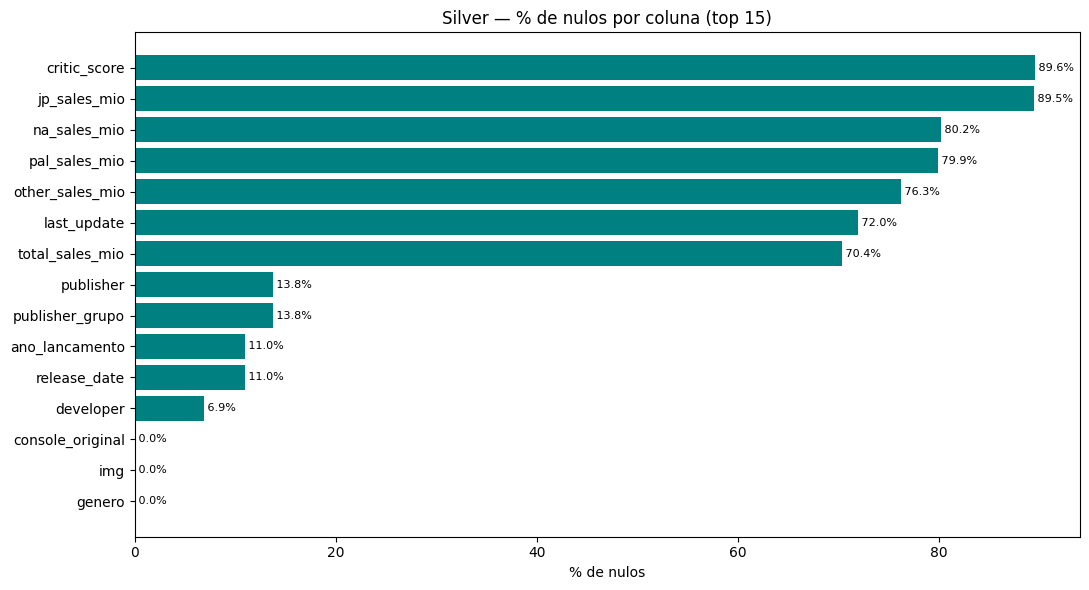

In [0]:
# perfil de qualidade DMBOK
import matplotlib.pyplot as plt

df_p = spark.table(SILVER)
n = df_p.count()
aggs = [F.sum(F.when(F.col(c).isNull(), 1)).cast("int").alias(c) for c in df_p.columns]
nulls = df_p.agg(*aggs).first()
prof = [(c, int(nulls[c]) if nulls[c] is not None else 0,
         round(100.0 * (nulls[c] or 0) / n, 1)) for c in df_p.columns]
pdf = (spark.createDataFrame(prof, ["coluna", "nulos", "pct_nulos"])
           .orderBy(F.col("pct_nulos").desc()))
print(f"\n🔎 Perfil de nulos — {SILVER} ({n} linhas)")
pdf.display()

top = pdf.limit(15).toPandas().sort_values("pct_nulos")
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top["coluna"], top["pct_nulos"], color="teal")
for y, v in enumerate(top["pct_nulos"]):
    ax.text(v, y, f" {v:.1f}%", va="center", fontsize=8)
ax.set_title("Silver — % de nulos por coluna (top 15)")
ax.set_xlabel("% de nulos")
plt.tight_layout()
plt.show()
plt.close(fig)